In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf

plt.style.use("seaborn-v0_8")


Load Stock Data (Reliance)

In [2]:
ticker = "RELIANCE.NS"

df = yf.download(
    ticker,
    start="2015-01-01",
    end="2025-01-01"
)

df = df[['Close']]
df.dropna(inplace=True)

df.head()


C:\Users\KRISHNENDU\AppData\Local\Temp\ipykernel_6872\1560446221.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,RELIANCE.NS
Date,
2015-01-01,189.999817
2015-01-02,189.496933
2015-01-05,187.421249
2015-01-06,178.915237
2015-01-07,182.809845


PRICE → RETURNS

In [3]:
df['Returns'] = df['Close'].pct_change()
df.dropna(inplace=True)

df.head()


Price,Close,Returns
Ticker,RELIANCE.NS,
Date,,
2015-01-02,189.496933,-0.002647
2015-01-05,187.421249,-0.010954
2015-01-06,178.915237,-0.045384
2015-01-07,182.809845,0.021768
2015-01-08,180.188477,-0.014339


Log Returns (Preferred in Finance)

In [4]:
df['Log_Returns'] = np.log(df['Close'] / df['Close'].shift(1))
df.dropna(inplace=True)


Visualize Returns

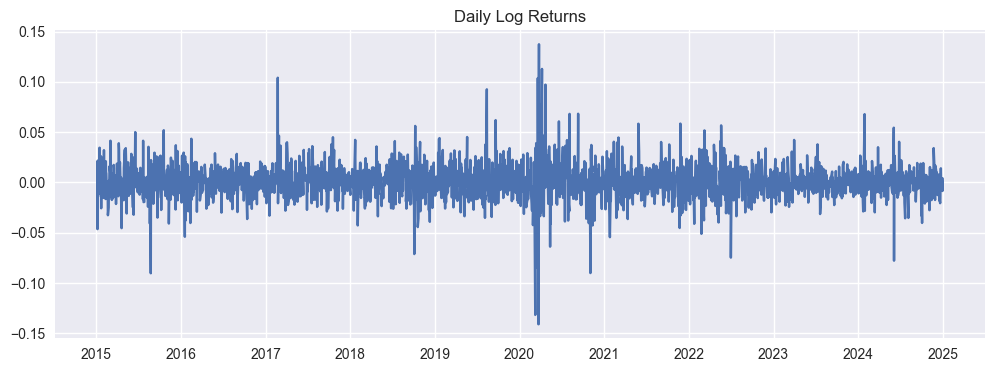

In [5]:
plt.figure(figsize=(12,4))
plt.plot(df['Log_Returns'])
plt.title("Daily Log Returns")
plt.show()


DISTRIBUTION OF RETURNS

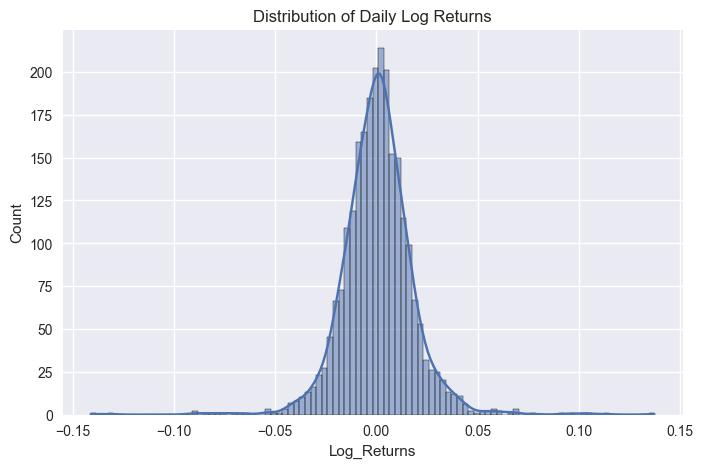

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df['Log_Returns'], bins=100, kde=True)
plt.title("Distribution of Daily Log Returns")
plt.show()


VOLATILITY (RISK MEASUREMENT)

In [7]:
df['Volatility_20'] = df['Log_Returns'].rolling(20).std() * np.sqrt(252)


Plot Volatility

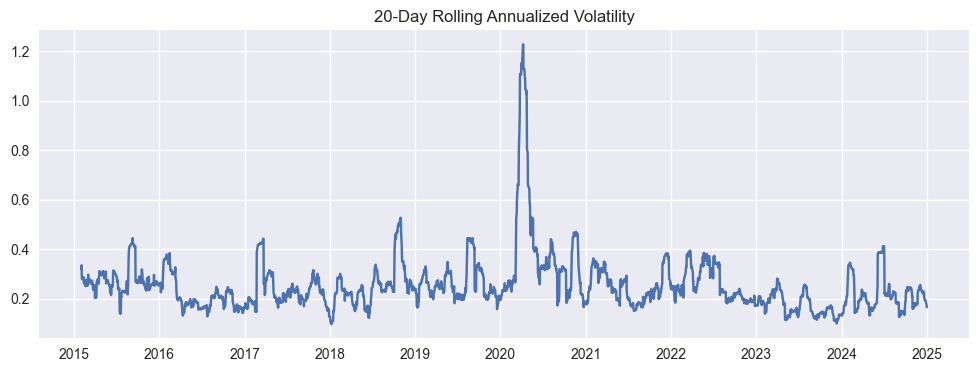

In [8]:
plt.figure(figsize=(12,4))
plt.plot(df['Volatility_20'])
plt.title("20-Day Rolling Annualized Volatility")
plt.show()


DRAWDOWN

In [9]:
df['Cumulative_Return'] = (1 + df['Returns']).cumprod()
df['Running_Max'] = df['Cumulative_Return'].cummax()
df['Drawdown'] = df['Cumulative_Return'] / df['Running_Max'] - 1


Plot Drawdown

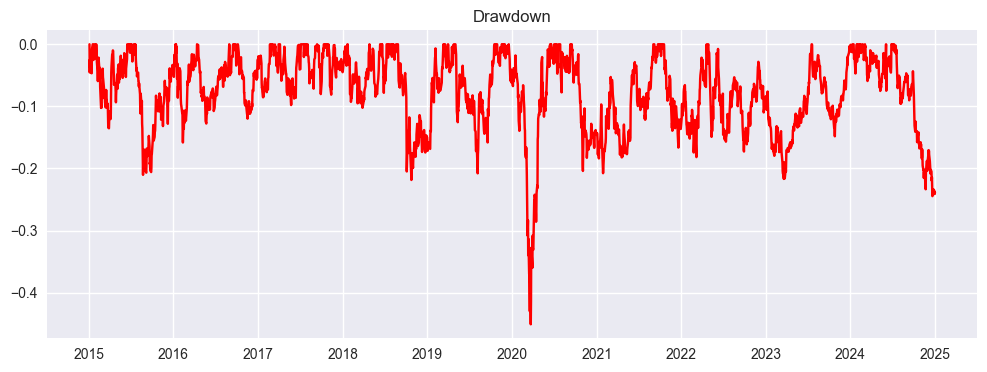

In [10]:
plt.figure(figsize=(12,4))
plt.plot(df['Drawdown'], color='red')
plt.title("Drawdown")
plt.show()


MULTI-STOCK ANALYSIS (INDIAN MARKET)

In [11]:
stocks = ["RELIANCE.NS", "TCS.NS", "INFY.NS", "HDFCBANK.NS"]

price_data = yf.download(
    stocks,
    start="2018-01-01",
    end="2025-01-01"
)['Close']

returns = price_data.pct_change().dropna()


C:\Users\KRISHNENDU\AppData\Local\Temp\ipykernel_6872\1925169322.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price_data = yf.download(
[*********************100%***********************]  4 of 4 completed


Correlation Heatmap

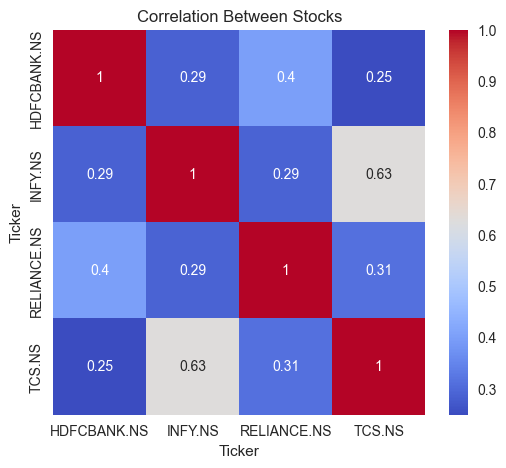

In [12]:
plt.figure(figsize=(6,5))
sns.heatmap(returns.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Stocks")
plt.show()
